In [1]:
import os
import json
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

data_dir_nx = os.path.join("plts", "next_word")
json_path_nx = os.path.join(data_dir_nx, "probing_results.json")
data_dir_fb = os.path.join("plts", "fill_in_the_blanks")
json_path_fb = os.path.join(data_dir_fb, "probing_results.json")

# laod
with open(json_path_nx, "w" if not os.path.exists(json_path_nx) else "r", encoding="utf-8") as f:
    results_nx = json.load(f)

with open(json_path_fb, "w" if not os.path.exists(json_path_fb) else "r", encoding="utf-8") as f:
    results_fb = json.load(f)

layers_nx = results_nx["general_metrics"]["layers"]
layers_fb = results_fb["general_metrics"]["layers"]

In [2]:
def plot_probing_results(num_layers, general_accuracies, ambiguous_accuracies, general_accuracies_2, ambiguous_accuracies_2, metric_string):
    layers = list(range(num_layers))
    plt.figure(figsize=(10, 6))
    plt.plot(layers, general_accuracies, marker='o', linestyle='-', linewidth=2, 
             color='blue', label=f'Fill blanks: General POS {metric_string}')
    plt.plot(layers, ambiguous_accuracies, marker='s', linestyle='--', linewidth=2, 
             color='dodgerblue', label=f'Fill blanks: Ambiguous Words POS {metric_string}')
    plt.plot(layers, general_accuracies_2, marker='o', linestyle='-', linewidth=2, 
             color='orange', label=f'Next Word: General POS {metric_string}')
    plt.plot(layers, ambiguous_accuracies_2, marker='s', linestyle='--', linewidth=2, 
             color='darkorange', label=f'Next Word: Ambiguous Words POS {metric_string}')
    all_data = general_accuracies + ambiguous_accuracies + general_accuracies_2 + ambiguous_accuracies_2
    min_val = min(all_data)
    max_val = max(all_data)
        
    plt.title('Probing Analysis: Layer-by-Layer POS Information', fontsize=14)
    plt.xlabel('Transformer Layer', fontsize=12)
    plt.ylabel(f'{metric_string}', fontsize=12)
    plt.xticks(layers)
    plt.ylim(min_val - 2, max_val + 1)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(fontsize=11, loc='lower right')
    plt.tight_layout()
    plt.show()

# Line Plots

## Plot for accuracy metric

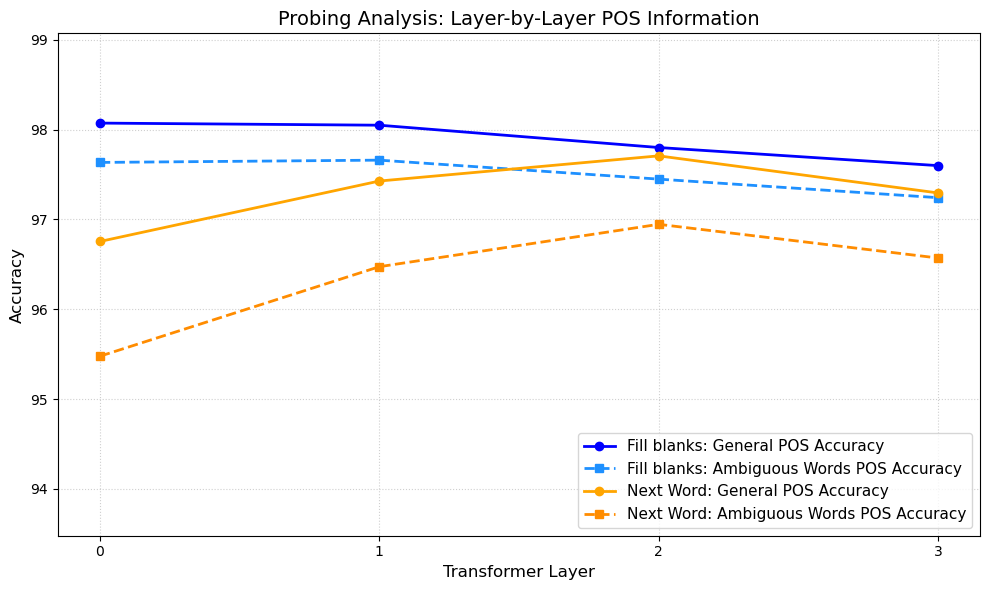

In [3]:
plot_probing_results(len(layers_fb), results_fb["general_metrics"]["accuracy"], results_fb["ambiguous_metrics"]["accuracy"], results_nx["general_metrics"]["accuracy"], results_nx["ambiguous_metrics"]["accuracy"], 'Accuracy')

## Plot for F1 metric

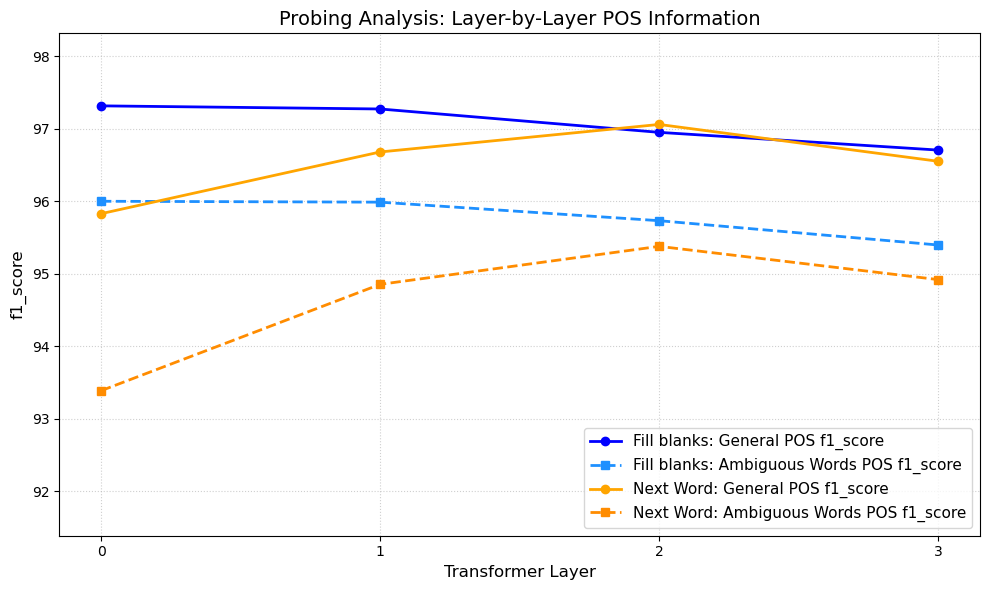

In [4]:
plot_probing_results(len(layers_fb), results_fb["general_metrics"]["f1_score"], results_fb["ambiguous_metrics"]["f1_score"], results_nx["general_metrics"]["f1_score"], results_nx["ambiguous_metrics"]["f1_score"], 'f1_score')

# Confusion Matrix

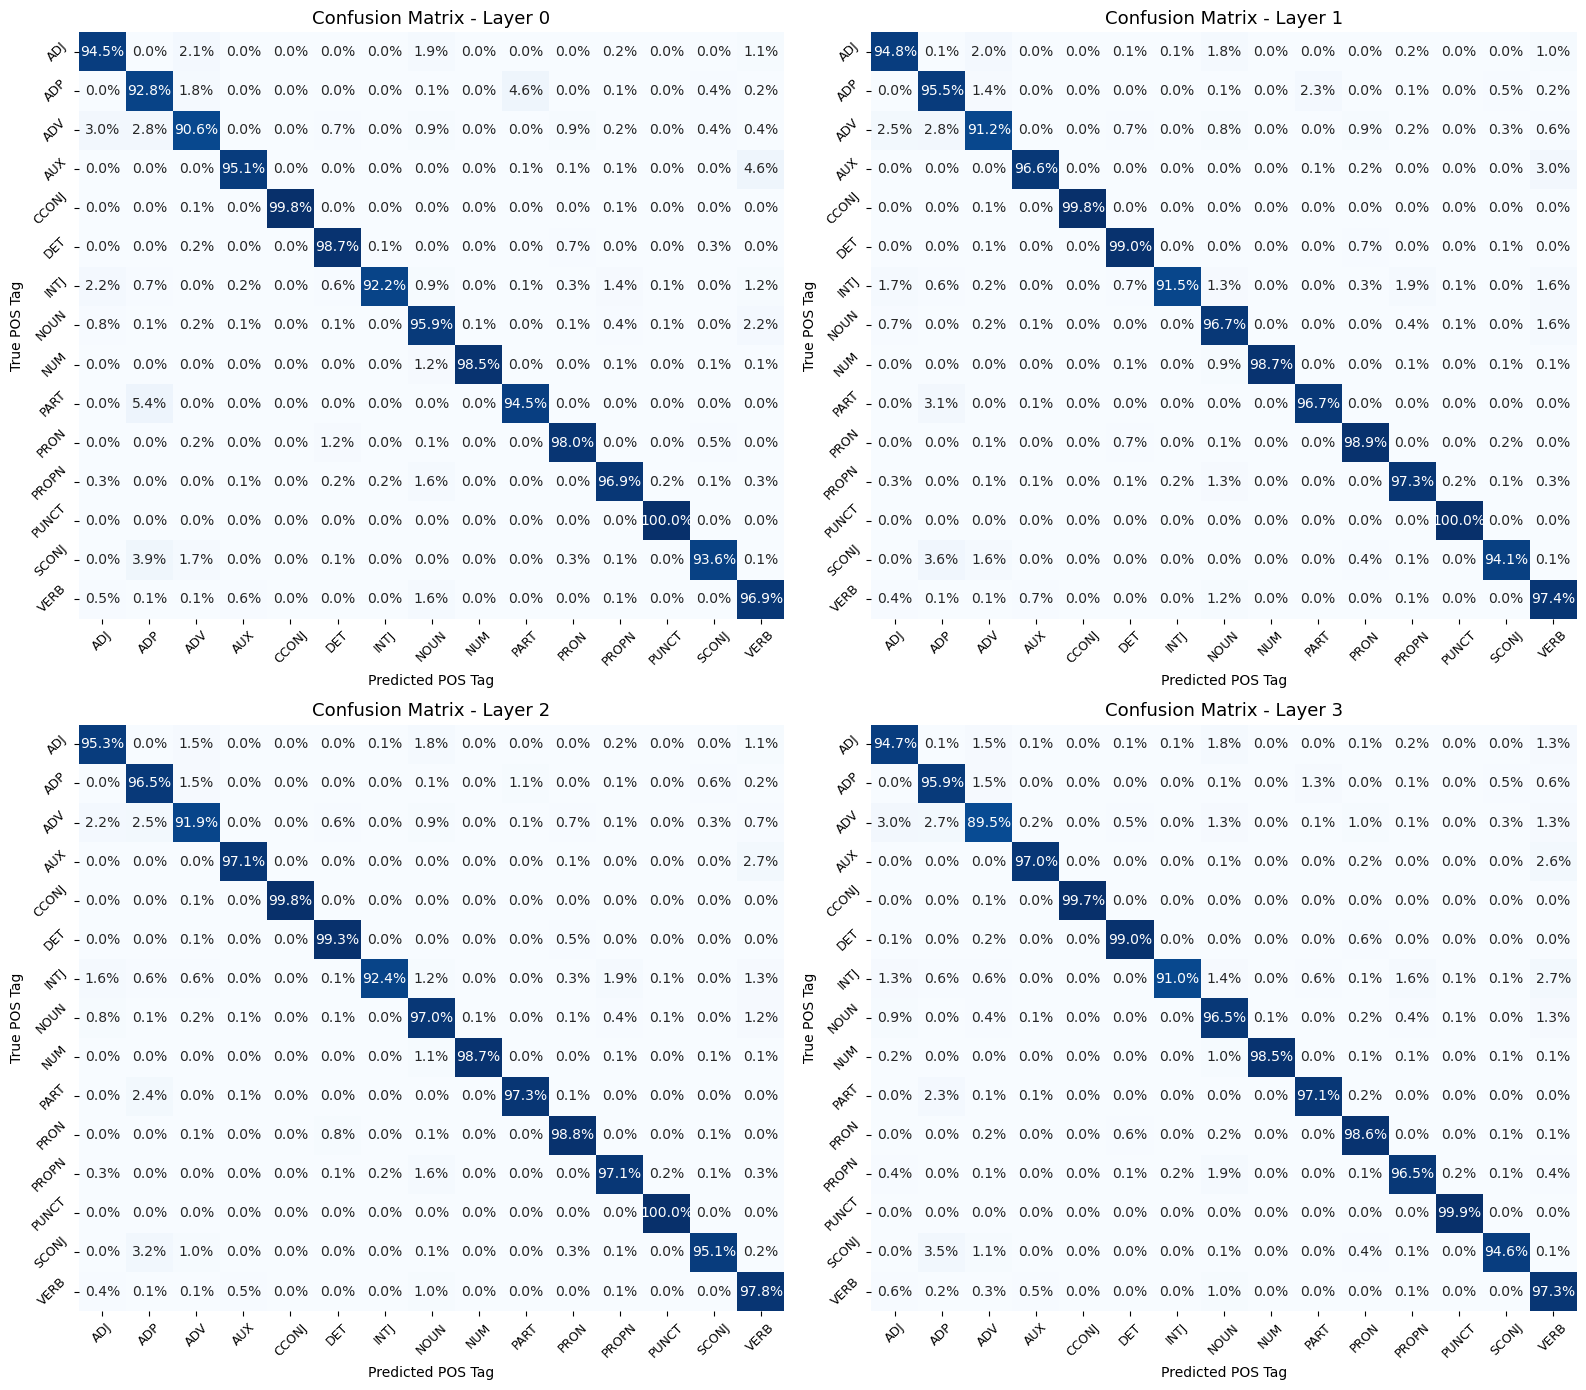

In [7]:
def confusion_matrix(data_dir):
    fig, axes = plt.subplots(2, 2, figsize=(16, 14))
    axes = axes.flatten()  
    for idx in range(4):
        matrix_file = os.path.join(data_dir, f"matrix_data_layer_{idx}.npy")
        data_package = np.load(matrix_file, allow_pickle=True).item()
        cm = data_package["matrix"]
        tag_names = data_package["tag_names"]
        
        
        # heatmap
        ax = axes[idx]
        sns.heatmap(cm, annot=True, fmt='.1%',cmap='Blues', xticklabels=tag_names, yticklabels=tag_names, ax=ax, cbar=False)
        
        ax.set_title(f'Confusion Matrix - Layer {idx}', fontsize=13)
        ax.set_xlabel('Predicted POS Tag', fontsize=10)
        ax.set_ylabel('True POS Tag', fontsize=10)
        ax.tick_params(axis='both', which='major', labelsize=9, labelrotation=45)
    
    plt.tight_layout()
    #plt.savefig(os.path.join(data_dir, "compiled_confusion_matrices.png"), dpi=300)
    plt.show()

confusion_matrix(data_dir_nx)

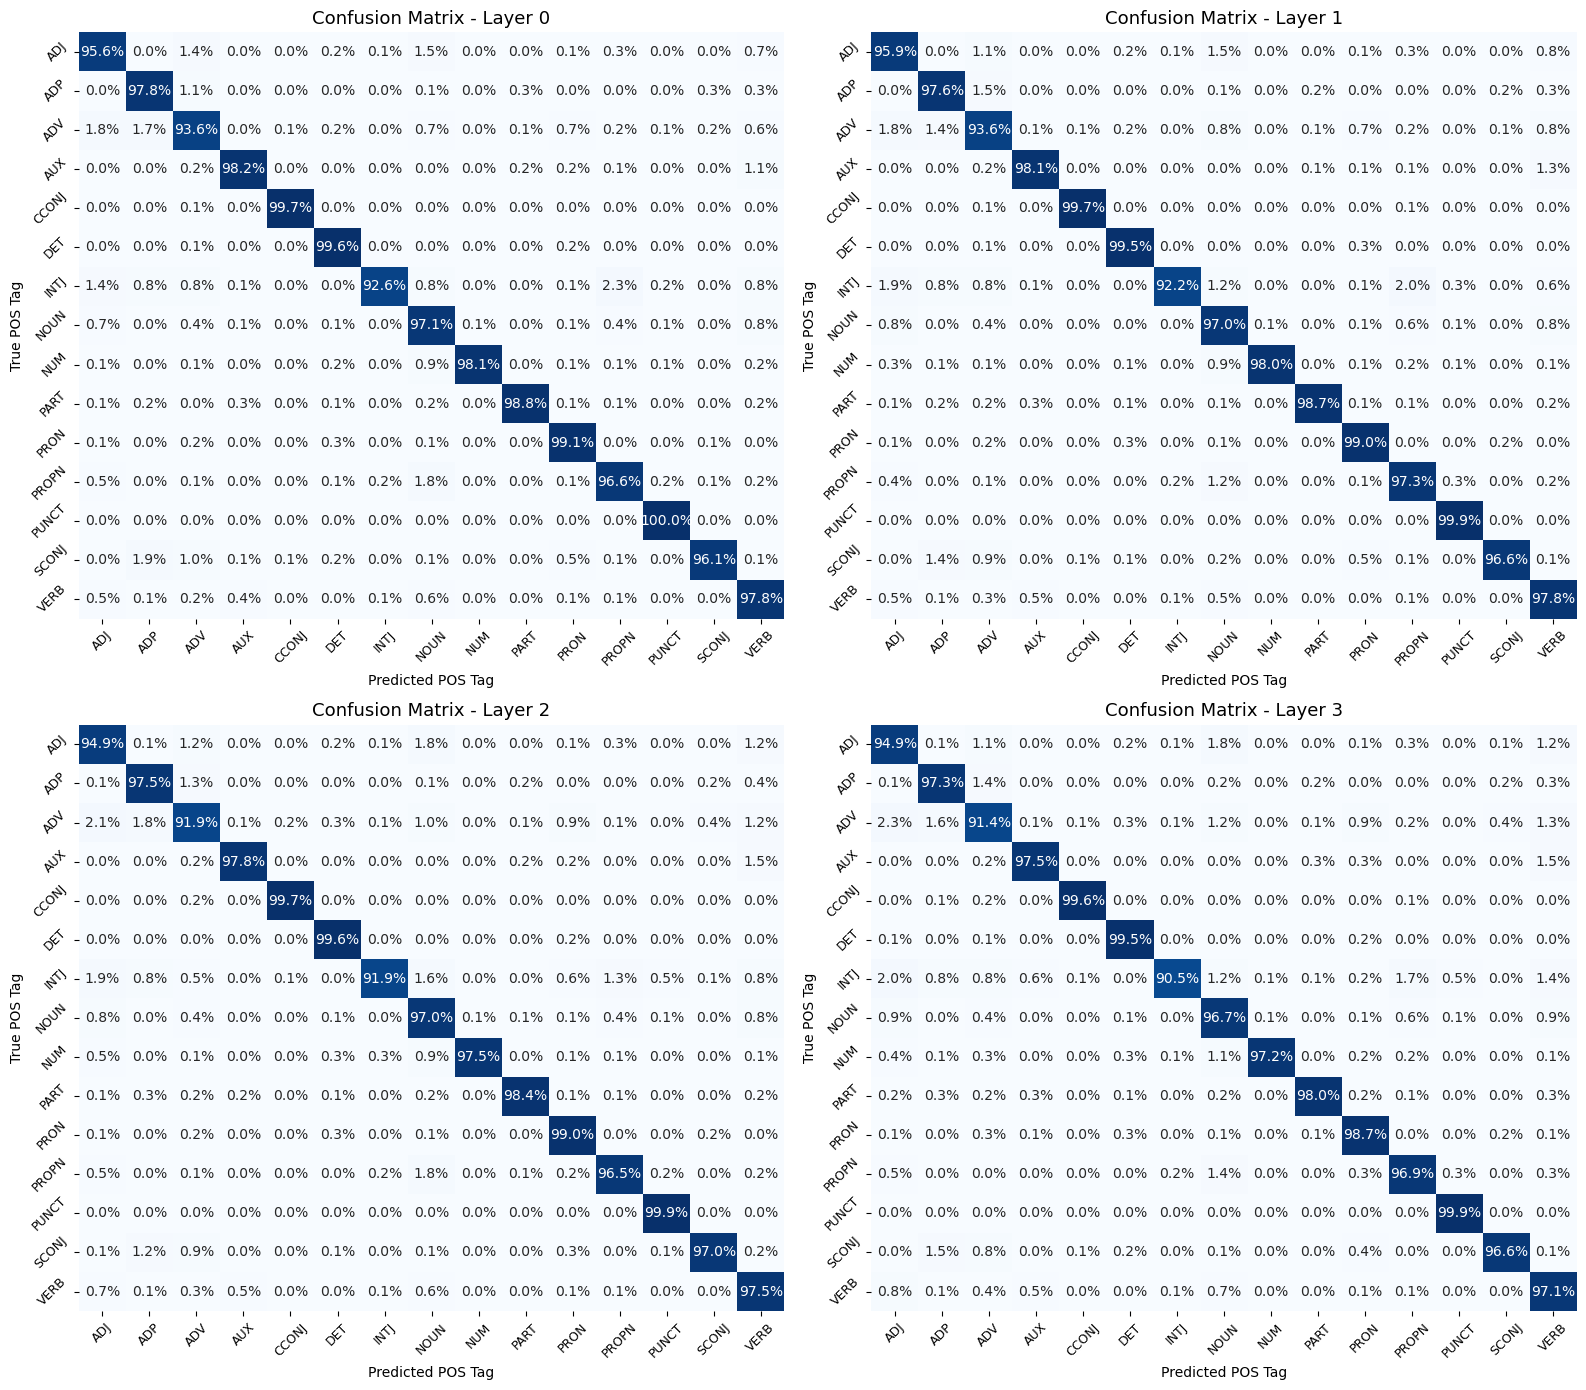

In [8]:
confusion_matrix(data_dir_fb)

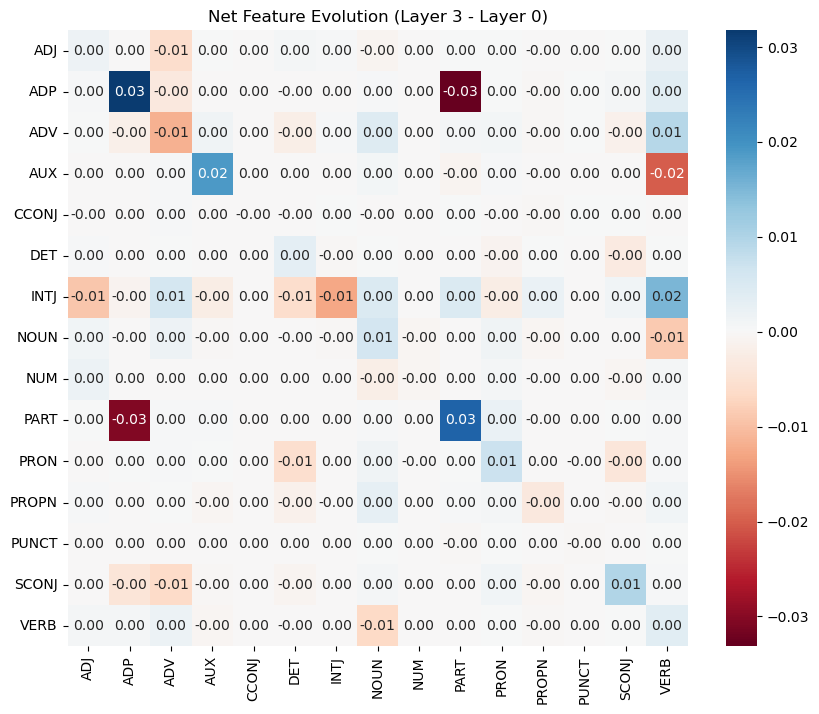

In [9]:
def net_change(data_dir):
    # Extract matrices
    cm_0 = np.load(os.path.join(data_dir, "matrix_data_layer_0.npy"), allow_pickle=True).item()["matrix"]
    cm_3 = np.load(os.path.join(data_dir, "matrix_data_layer_3.npy"), allow_pickle=True).item()["matrix"]
    tag_names = np.load(os.path.join(data_dir, "matrix_data_layer_3.npy"), allow_pickle=True).item()["tag_names"]
    
    # normalized delta
    cm_0_norm = cm_0 / cm_0.sum(axis=1, keepdims=True)
    cm_3_norm = cm_3 / cm_3.sum(axis=1, keepdims=True)
    delta_matrix = cm_3_norm - cm_0_norm
    
    # Plot delta Matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(delta_matrix, annot=True, fmt='.2f', cmap='RdBu', center=0, xticklabels=tag_names, yticklabels=tag_names)
    plt.title("Net Feature Evolution (Layer 3 - Layer 0)", fontsize=12)
    plt.show()

net_change(data_dir_nx)

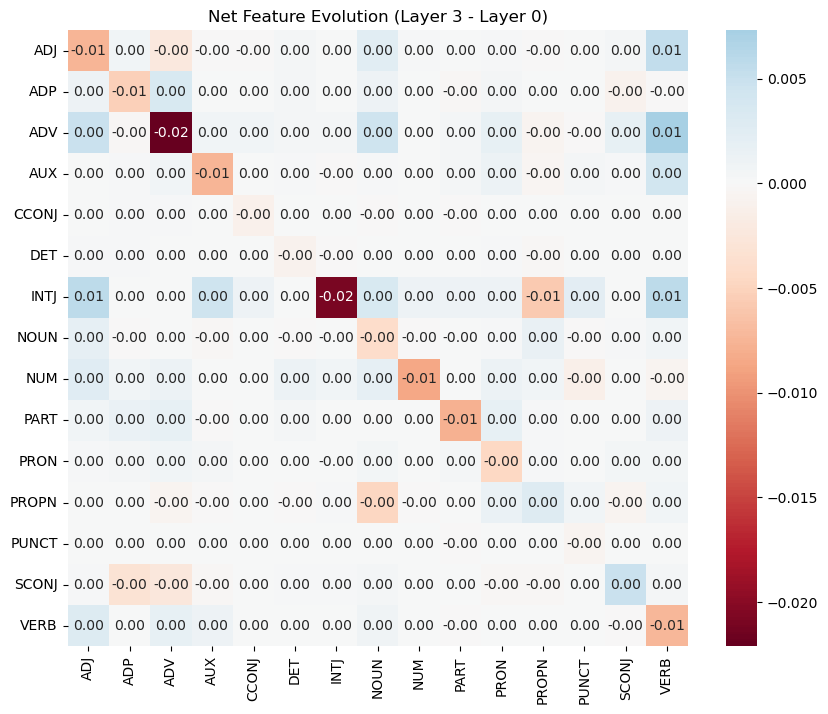

In [10]:
net_change(data_dir_fb)

In [ ]:
def plot_classification_reports(target_dir, num_layers=4):
    """Generates a 2x2 grid of heatmaps for individual class performance."""
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))
    axes = axes.flatten()

    for idx in range(num_layers):
        matrix_file = os.path.join(target_dir, f"matrix_data_layer_{idx}.npy")
        if not os.path.exists(matrix_file):
            print(f"Skipping layer {idx}: File missing at {matrix_file}")
            continue
            
        # Unpack binary numpy storage block
        data_package = np.load(matrix_file, allow_pickle=True).item()
        cm = data_package["matrix"]
        tag_names = data_package["tag_names"]
        tag_ids = data_package["tag_ids"]
        
        # Reconstruct precision/recall/f1 arrays directly from raw confusion totals
        # This approach mathematically calculates performance indicators dynamically
        tp = np.diag(cm)
        fp = np.sum(cm, axis=0) - tp
        fn = np.sum(cm, axis=1) - tp
        
        precision = np.where((tp + fp) > 0, tp / (tp + fp), 0.0)
        recall = np.where((tp + fn) > 0, tp / (tp + fn), 0.0)
        f1_score = np.where((precision + recall) > 0, 2 * (precision * recall) / (precision + recall), 0.0)
        
        # Structure vectors into structured DataFrame
        df_report = pd.DataFrame({
            'precision': precision,
            'recall': recall,
            'f1-score': f1_score
        }, index=tag_names)
        
        # Plot target metrics on corresponding axis index
        ax = axes[idx]
        sns.heatmap(
            df_report, 
            annot=True, 
            cmap='RdYlGn', 
            fmt='.2f', 
            vmin=0.0, 
            vmax=1.0, 
            ax=ax,
            cbar=(idx in [1, 3])
        )
        
        ax.set_title(f'Classification Report - Layer {idx}', fontsize=13, fontweight='bold')
        ax.set_xticklabels(['Precision', 'Recall', 'F1-Score'], fontsize=11)
        ax.tick_params(axis='y', labelsize=10)

    plt.tight_layout()
    
    plt.savefig(save_path, dpi=300)
    plt.show()



# =====================================================================
# RUN ANALYSIS FOR BOTH EXPERIMENTAL TRACKS
# =====================================================================
print("--- PROCESSING NEXT WORD EXPERIMENT MATRICES ---")
plot_classification_reports(data_dir_nx)

print("--- PROCESSING FILL IN THE BLANKS EXPERIMENT MATRICES ---")
plot_classification_reports(data_dir_fb)